In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from joblib import load
from tqdm import tqdm
import warnings

from sklearn.metrics import classification_report
warnings.filterwarnings("ignore")
import glob
import os
from collections import OrderedDict 
 
import numpy as np
import matplotlib.pyplot as plt  

import pandas as pd 


In [2]:
import pandas as pd
pd.read_parquet('/home/mdelafuente/sixplusdets/2021_plussixdet_oids_.parquet')

,ndet,mjdstarthist
oid,,
ZTF21acjruxj,15,NaN
ZTF18abkeeso,6,NaN
ZTF18absqwco,19,NaN
ZTF21acdhdtn,7,NaN
ZTF22aaxvmbi,9,NaN
...,...,...
ZTF21aagtymv,30,59248.552697
ZTF23aagpxee,9,59248.554583
ZTF21aahuchf,8,59248.458102


In [3]:
import yaml
from src.data.modules.LitData  import LitData
from src.layers.selfsupervised.lightcurve import LightCurveClassifier
DICT = {
    "AGN": 0,
    "QSO": 1,
    "EA": 2,
    "YSO": 3,
    "SNIa": 4,
    "CV/Nova": 5,
    "RRLc": 6,
    "RSCVn": 7,
    "Blazar": 8,
    "SNII": 9,
    "EB/EW": 10,
    "LPV": 11,
    "CEP": 12,
    "RRLab": 13,
    "Periodic-Other": 14,
    "DSCT": 15,
    "SNIbc": 16,
    "SLSN": 17,
    "TDE": 18,
    "SNIIb": 19,
    "SNIIn": 20,
    "Microlensing": 21
    }
def produce_report(path_1):
    path_args = glob.glob(f"{path_1}*args*")[0]
    #print(path_args)
    with open(path_args, 'r') as file:
        args = yaml.safe_load(file)
    #print('Initializing models') 
    model = LightCurveClassifier(**args) 
    #print('Loading checkpoints')
    checkpoint_path_clip = glob.glob(
        f"{path_1}*my_best_checkpoint*"
    ) 
    #print(checkpoint_path_clip[-1])
    checkpoint_clip = torch.load(checkpoint_path_clip[-1], map_location=torch.device('cuda:2'))
    od_atat = OrderedDict() 
    for key in checkpoint_clip["state_dict"].keys(): 
            #print(key)
            if 'project' in key:
                continue
            if 'model' in key:
                od_atat[key.replace("model.", "")] = checkpoint_clip["state_dict"][key]

    model.load_state_dict(od_atat,strict=True)
    args['general']['data_root'] = 'data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12'
    args['general']['use_sampler'] = False
    args['general']['batch_size'] = 256

    pl_datal = LitData(**args['general'])
    dataloader = pl_datal.test_dataloader() 
    target = None
    preds_out = None

    model.eval().to(device = 'cuda:2')  

    for b1 in tqdm(dataloader):

        #print(b1.keys())
        b1 = {key:value.to(device = 'cuda:2') for key, value in b1.items()}
        #print(b1['mask'].sum(dim = [1,2])[0])
        lc_emb = model(**b1)  
        t = b1['labels']
        preds_out = (
            np.concatenate([preds_out, torch.argmax(lc_emb, axis=1).detach().cpu().numpy()])
            if preds_out is not None
            else torch.argmax(lc_emb, axis=1).cpu().detach().numpy()
        )
        target = (
            np.concatenate([target, t.cpu().detach().numpy()])
            if target is not None
            else t.detach().cpu().numpy()
        )
    results = preds_out
    classification = classification_report(target, results, target_names=list(DICT.keys()),digits = 4)
    print(classification)
    data_dict =  classification_report(target, results, target_names=list(DICT.keys()),digits = 4, output_dict=True)    
    from src.utils.plottinglib import elasticc_confusion_matrix
    out_metrics_balto = classification_report(
        target, results, target_names=list(DICT.keys()), output_dict=True
    )["macro avg"]
    template_balto = ""
    for key in out_metrics_balto.keys():
        template_balto += " {} : {:.3f} ".format(key.upper(), out_metrics_balto[key])
    fig, axes = plt.subplots(1, 1, figsize=(12, 12))
    elasticc_confusion_matrix(
        y_true=np.array(target).astype(int),
        y_pred=np.array(results).astype(int),
        classes= np.array(list(DICT.keys())),
        ax=axes,
        normalize=True,
        title=f" FClassifier Results [TEST] \n\n {template_balto}",
    )
    plt.show()
    return data_dict

using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:22<00:00,  8.82it/s]


                precision    recall  f1-score   support

           AGN     0.4763    0.3494    0.4031      3935
           QSO     0.6010    0.5071    0.5500      4108
            EA     0.8604    0.6937    0.7681      4352
           YSO     0.5846    0.5411    0.5620      3295
          SNIa     0.4846    0.3766    0.4238      2175
       CV/Nova     0.5685    0.5401    0.5539      1944
          RRLc     0.7861    0.7363    0.7604      4243
         RSCVn     0.5679    0.6248    0.5950      3124
        Blazar     0.3037    0.4745    0.3704      1709
          SNII     0.2711    0.3885    0.3194      1040
         EB/EW     0.7167    0.7478    0.7319      4615
           LPV     0.8528    0.7676    0.8079      4135
           CEP     0.6931    0.5633    0.6215      3508
         RRLab     0.7592    0.6873    0.7215      4423
Periodic-Other     0.2757    0.5652    0.3706       874
          DSCT     0.4558    0.6605    0.5394      2059
         SNIbc     0.1272    0.2714    0.1732  

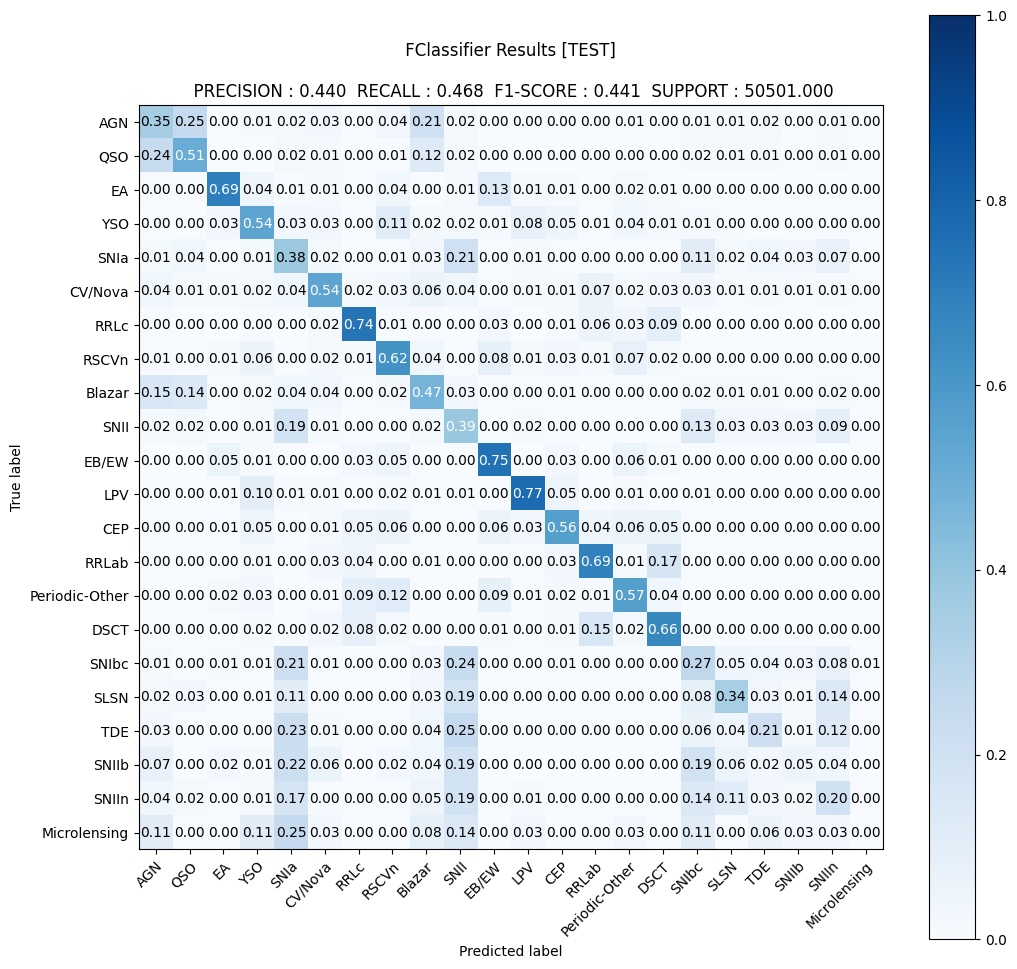

In [4]:
data_dict_1 = produce_report('/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/ZTF_ff/LC/MLP_v0_pretrained_0/')

In [5]:
data_dict_2 = produce_report('/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/ZTF_ff/LC/MLP_WINDOWS_v0_tmask_0/')

IndexError: list index out of range

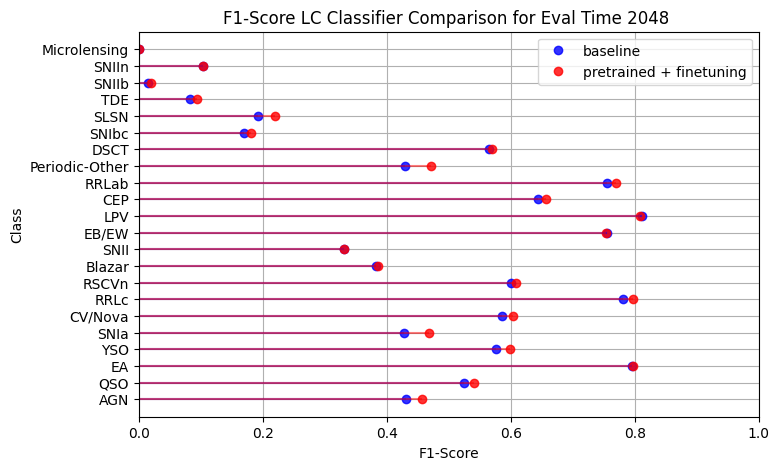

In [6]:
def compare_models(d1,d2, eval_time= 2048):

    f1_baseline = []
    f1_finetune = []

    fig,ax = plt.subplots(1,1,figsize = (8,5))
    for key,value in data_dict_1.items():
        if key in DICT.keys():
            #print(key,value)
            f1_baseline.append(value['f1-score'])
    df_1 = pd.DataFrame({'group':DICT.keys(), 'values':f1_baseline })
    ordered_df_1 = df_1#.sort_values(by='values')
    my_range_1=range(1,len(df_1.index)+1)
    

    for key,value in data_dict_2.items():
        if key in DICT.keys():
            #print(key,value)
            f1_finetune.append(value['f1-score'])
    df_2 = pd.DataFrame({'group':DICT.keys(), 'values':f1_finetune})
    ordered_df_2 = df_2#.sort_values(by='values')
    my_range_2=range(1,len(df_2.index)+1)
    plt.plot(ordered_df_1['values'].values, my_range_1, "o", alpha = 0.8,color='blue')
    plt.plot(ordered_df_2['values'].values, my_range_2, "o", alpha = 0.8,color='red')

    plt.legend(['baseline','pretrained + finetuning'])
    
    # The horizontal plot is made using the hline function
    plt.hlines(y=my_range_1, xmin=0, xmax=ordered_df_1['values'], color='blue', alpha = 0.5)
    
    # The horizontal plot is made using the hline function
    plt.hlines(y=my_range_2, xmin=0, xmax=ordered_df_2['values'], color='red', alpha = 0.5)

    # Add titles and axis names
    plt.yticks(my_range_1, ordered_df_1['group'])
    plt.title(f"F1-Score LC Classifier Comparison for Eval Time {eval_time} ", loc='center')

    plt.xlabel('F1-Score')
    plt.ylabel('Class')
    plt.xlim(0,1)
    #plt.xticks(np.arange(0,1,50), ordered_df_1['group'])
    plt.grid('on', )
    # Show the plot
    plt.show()
compare_models(data_dict_1,data_dict_2)

In [7]:
transient =  {
    "SNIa": 4,
    "SNII": 9,
    "SNIbc": 16,
    "SLSN": 17,
    "TDE": 18,
    "SNIIb": 19,
    "SNIIn": 20,
    "Microlensing": 21
}
stochastic =  {
    "AGN": 0,
    "QSO": 1,
    "YSO": 3,
    "CV/Nova": 5,
    "Blazar": 8,
}
periodic =  {
    "EA": 2,
    "RRLc": 6,
    "RSCVn": 7,
    "EB/EW": 10,
    "LPV": 11,
    "CEP": 12,
    "RRLab": 13,
    "Periodic-Other": 14,
    "DSCT": 15,
}

In [8]:

trans_f1 = []
stoch_f1 = []
per_f1 = []
for class_key, value in data_dict_1.items():
    #print(class_key)
    if class_key in DICT.keys():
        
        if class_key in transient.keys():
            trans_f1.append(value['f1-score'])
        if class_key in stochastic.keys():
            stoch_f1.append(value['f1-score'])
        if class_key in periodic.keys():
            per_f1.append(value['f1-score'])
print('group eval:')
print('trans',np.mean(trans_f1))
print('stoch',np.mean(stoch_f1))

print('per',np.mean(per_f1))


group eval:
trans 0.16527718452725348
stoch 0.5000840900708614
per 0.6820030672330036


In [9]:

trans_f1 = []
stoch_f1 = []
per_f1 = []
for class_key, value in data_dict_2.items():
    #print(class_key)
    if class_key in DICT.keys():
        
        if class_key in transient.keys():
            trans_f1.append(value['f1-score'])
        if class_key in stochastic.keys():
            stoch_f1.append(value['f1-score'])
        if class_key in periodic.keys():
            per_f1.append(value['f1-score'])
print('group eval:')    
print('trans',np.mean(trans_f1))
print('stoch',np.mean(stoch_f1))
print('per',np.mean(per_f1))

group eval:
trans 0.17713164464626668
stoch 0.5170093470867985
per 0.6926558102716476


In [10]:
def early_as(path_1:str, before_time:int,supress_cm = False,supress_dict = False):
    path_args = glob.glob(f"{path_1}*args*")[0]
    #print(path_args)
    with open(path_args, 'r') as file:
        args = yaml.safe_load(file)
    #print('Initializing models') 
    model = LightCurveClassifier(**args) 
    #print('Loading checkpoints')
    checkpoint_path_clip = glob.glob(
        f"{path_1}*my_best_checkpoint*"
    ) 
    #print(checkpoint_path_clip[-1])
    checkpoint_clip = torch.load(checkpoint_path_clip[-1], map_location=torch.device('cuda:2'))
    od_atat = OrderedDict() 
    for key in checkpoint_clip["state_dict"].keys(): 
            #print(key)
            if 'project' in key:
                continue
            if 'model' in key:
                od_atat[key.replace("model.", "")] = checkpoint_clip["state_dict"][key]

    model.load_state_dict(od_atat,strict=True)
    args['general']['data_root'] = 'data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12'
    args['general']['use_sampler'] = False
    args['general']['batch_size'] = 256

    pl_datal = LitData(**args['general'])
    dataloader = pl_datal.test_dataloader() 
    target = None
    preds_out = None

    model.eval().to(device = 'cuda:2')  

    for b1 in tqdm(dataloader):

        #print(b1.keys())
        b1 = {key:value.to(device = 'cuda:2') for key, value in b1.items()}
        #print(b1['time'].shape,b1['mask'].shape)
        b1['mask'] = (b1['time'] <= before_time)
        lc_emb = model(**b1)  
        t = b1['labels']
        preds_out = (
            np.concatenate([preds_out, torch.argmax(lc_emb, axis=1).detach().cpu().numpy()])
            if preds_out is not None
            else torch.argmax(lc_emb, axis=1).cpu().detach().numpy()
        )
        target = (
            np.concatenate([target, t.cpu().detach().numpy()])
            if target is not None
            else t.detach().cpu().numpy()
        )
    results = preds_out
    classification = classification_report(target, results, target_names=list(DICT.keys()),digits = 4)
    data_dict =  classification_report(target, results, target_names=list(DICT.keys()),digits = 4, output_dict=True)    
    if supress_dict == 0:
        print(classification)
    if supress_cm == 0:        
        from src.utils.plottinglib import elasticc_confusion_matrix
        out_metrics_balto = classification_report(
            target, results, target_names=list(DICT.keys()), output_dict=True
        )["macro avg"]
        template_balto = ""
        for key in out_metrics_balto.keys():
            template_balto += " {} : {:.3f} ".format(key.upper(), out_metrics_balto[key])
        fig, axes = plt.subplots(1, 1, figsize=(12, 12))
        elasticc_confusion_matrix(
            y_true=np.array(target).astype(int),
            y_pred=np.array(results).astype(int),
            classes= np.array(list(DICT.keys())),
            ax=axes,
            normalize=True,
            
            title=f" FClassifier Results [TEST] \n\n {template_balto}",
        )
        plt.show()
    
    return data_dict

In [11]:
data_dict_1['macro avg']['f1-score']

0.4527575241667894

using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:22<00:00,  9.00it/s]


using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:22<00:00,  8.96it/s]


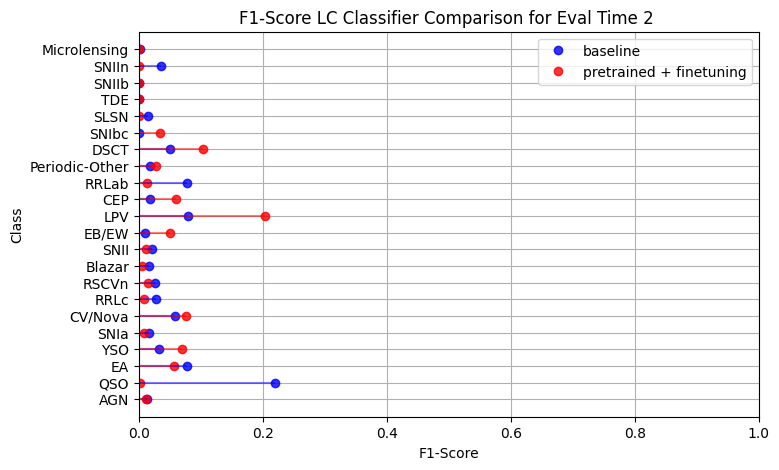

using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:22<00:00,  8.96it/s]


using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:22<00:00,  8.92it/s]


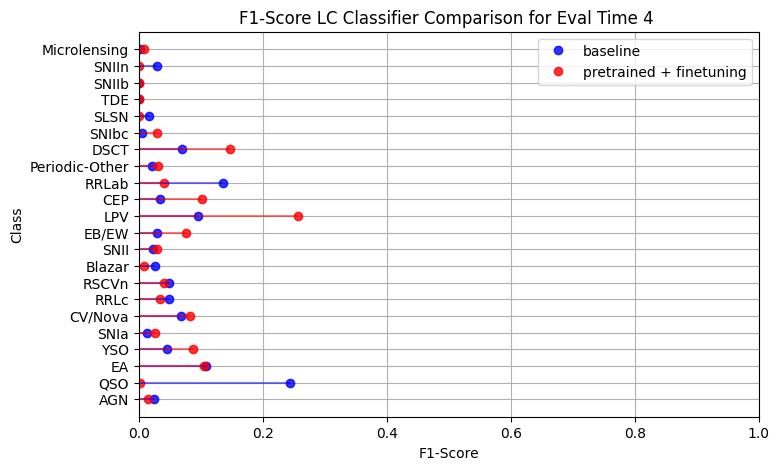

using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:22<00:00,  8.92it/s]


using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:22<00:00,  8.90it/s]


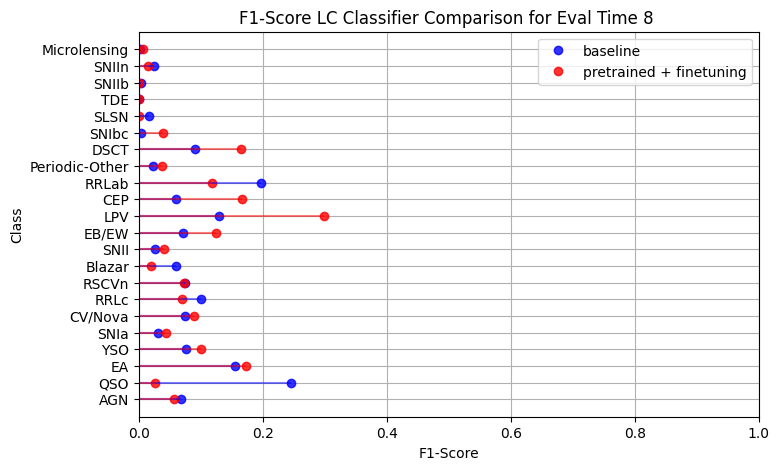

using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:22<00:00,  8.88it/s]


using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:22<00:00,  8.90it/s]


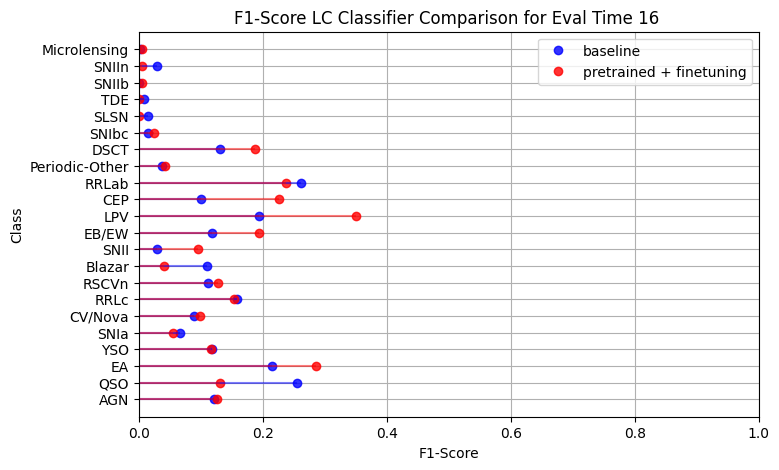

using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:22<00:00,  8.85it/s]


using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:22<00:00,  8.86it/s]


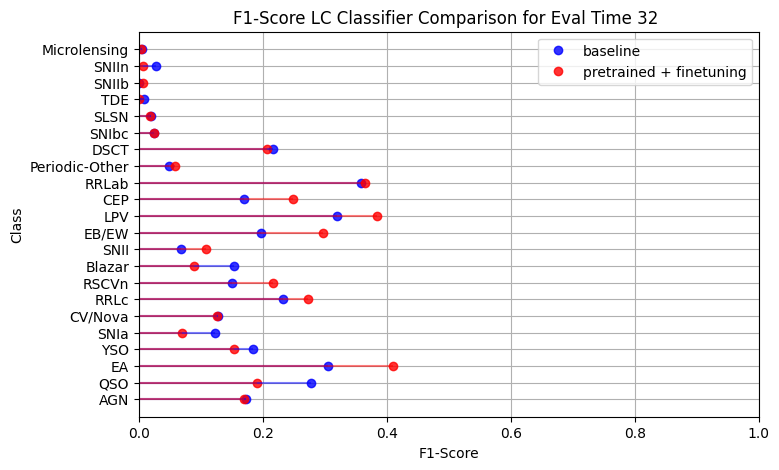

using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:22<00:00,  8.84it/s]


using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:22<00:00,  8.83it/s]


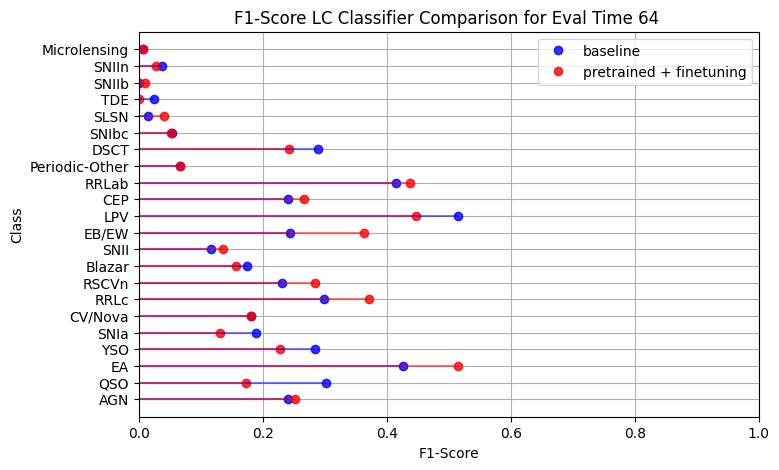

using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:22<00:00,  8.81it/s]


using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:22<00:00,  8.81it/s]


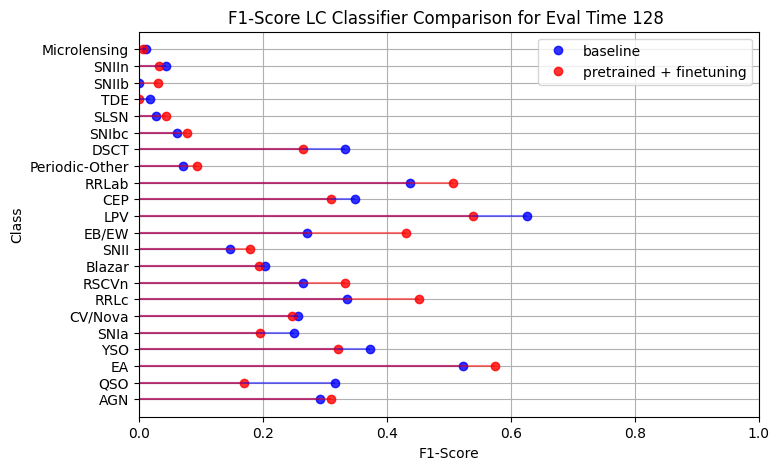

using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:22<00:00,  8.79it/s]


using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:22<00:00,  8.78it/s]


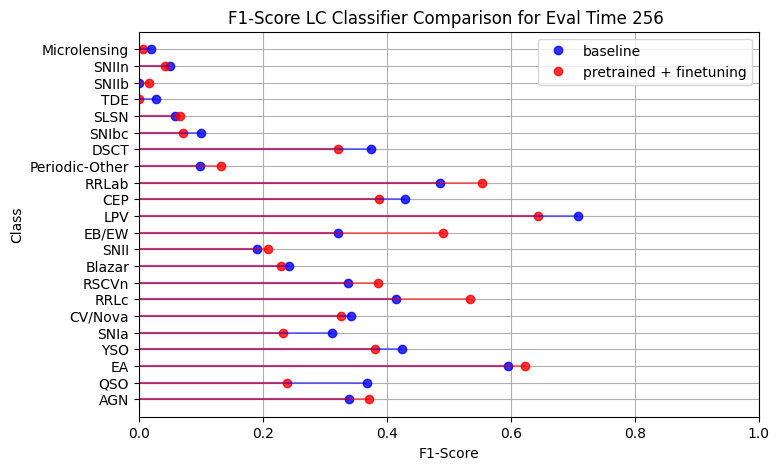

using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:22<00:00,  8.82it/s]


using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:22<00:00,  8.79it/s]


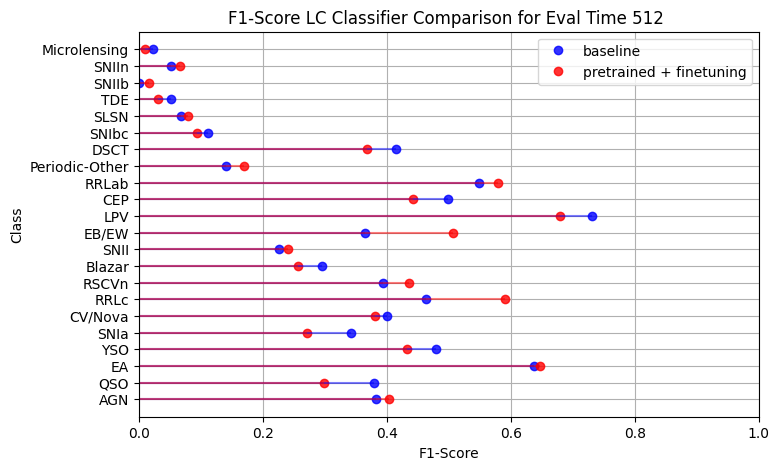

using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:22<00:00,  8.76it/s]


using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:22<00:00,  8.80it/s]


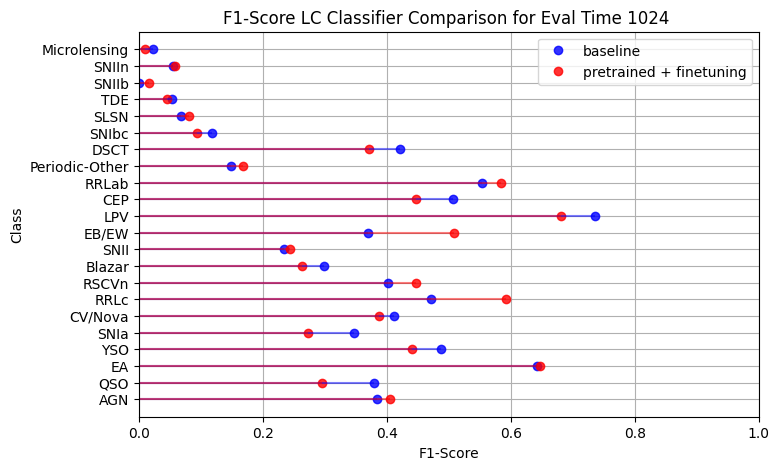

using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:22<00:00,  8.76it/s]


using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 198/198 [00:22<00:00,  8.73it/s]


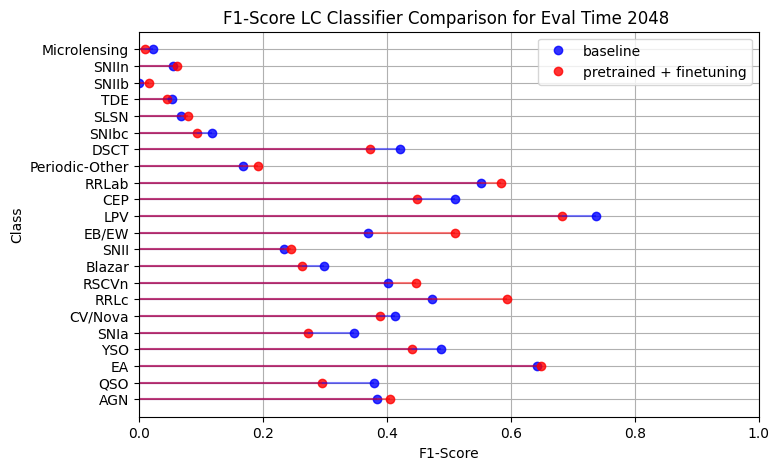

In [12]:
e_times = [2,4,8,16,32,64,128,256,512,1024,2048]
macro_f1_eval_times = {'d1':[],'d2':[]}
for eval_time in e_times:
    data_dict_1 = early_as('/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/ZTF_ff/LC/MLP_baseline_0/', before_time = eval_time,supress_cm=True,supress_dict=True)
    data_dict_2 = early_as('/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/ZTF_ff/LC/MLP_WINDOWS_v0_0/', before_time = eval_time,supress_cm=True,supress_dict=True)
    macro_f1_eval_times['d1'].append(data_dict_1['macro avg']['f1-score'])
    macro_f1_eval_times['d2'].append(data_dict_2['macro avg']['f1-score'])
    compare_models(data_dict_1,data_dict_2,eval_time)

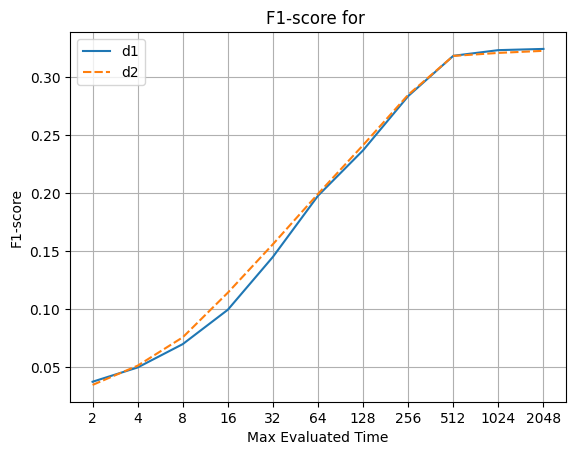

In [13]:
import seaborn as sns

sns.lineplot(macro_f1_eval_times)
#plt.legend(['baseline','pretrained'])

plt.title('F1-score for ')
plt.xticks(list(range(len(e_times))),[str(time) for time in e_times])
plt.xlabel('Max Evaluated Time')
plt.ylabel('F1-score')
plt.grid('on')